In [7]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [8]:
X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

In [9]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [10]:
df.shape

(100, 3)

In [11]:
df.head()

,feature1,feature2,target
0,0.056066,1.213991,58.226606
1,-0.254380,-0.333373,-110.919360
2,0.846508,0.469477,80.571729
3,-0.051291,1.056255,59.454570
4,-0.539678,0.721333,60.475270


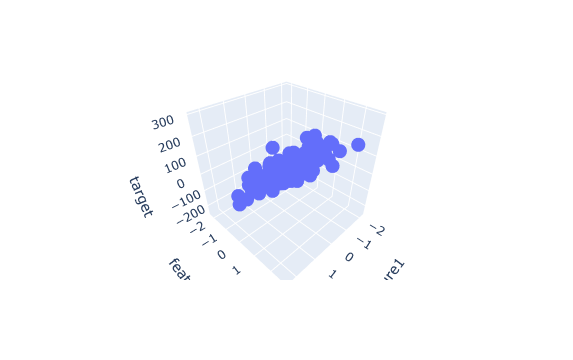

In [12]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.show()

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [14]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))



MAE 50.018398658040134
MSE 3686.221582812789
R2 score 0.6961939996267419


In [15]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)
final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

z = z_final



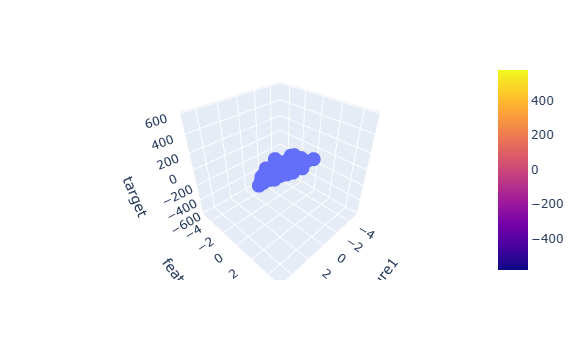

In [16]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()

In [17]:
lr.coef_

array([16.560446  , 98.97460144])

In [18]:
lr.intercept_

np.float64(-2.262049238511814)